In [39]:
import pandas as pd 
import matplotlib as plt
import numpy as np 
import seaborn as sns

In [20]:
#Histórico_Compras -   fecha, nombre_articulo, unidades
#Clasificación_Articulos -   nombre_articulo, categoria

data=pd.read_excel('Datos_CLV_2026_Tec_v2.xlsx', sheet_name='Histórico_Compras')
data2=pd.read_excel('Datos_CLV_2026_Tec_v2.xlsx', sheet_name='Clasificación_Articulos')

In [21]:
#Proceso para Histórico compras
data.head()

,folio,fecha,articulo_id,clave_articulo,nombre_articulo,unidades,precio_unitario,precio_total_neto
0,C1,2021-03-18T00:00:00Z,82369,179212,JAEGER SPINDLE MOTION,1,77289.5600,77289.56
1,C2,2021-03-30T00:00:00Z,83401,AR175,REPL BLOWER 120V INFINITY,1,4008.3300,4008.33
2,C2,2021-03-30T00:00:00Z,83404,AR176,REPL BLOWER 230V INFINITY,1,4008.3300,4008.33
3,C2,2021-03-30T00:00:00Z,83407,AG205-5,FILTER BAGS YELLOW F205 5/BX,50,2111.9158,105595.79
4,C2,2021-03-30T00:00:00Z,83424,1-0052-0014,IVAC 2.B TWIN INFINITY 120V,1,37920.5900,37920.59


In [22]:
data[['fecha', 'nombre_articulo', 'unidades']].info()

<class 'pandas.DataFrame'>
RangeIndex: 9186 entries, 0 to 9185
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   fecha            9186 non-null   str  
 1   nombre_articulo  9186 non-null   str  
 2   unidades         9186 non-null   int64
dtypes: int64(1), str(2)
memory usage: 215.4 KB


In [23]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = data['fecha'].value_counts().reset_index()
Tabla_freq

,fecha,count
0,2021-09-06T00:00:00Z,471
1,2025-09-01T00:00:00Z,430
2,2026-04-14T00:00:00Z,367
3,2025-01-14T00:00:00Z,357
4,2022-03-10T00:00:00Z,348
...,...,...
397,2026-08-06T00:00:00Z,1
398,2026-08-10T00:00:00Z,1
399,2026-08-12T00:00:00Z,1
400,2026-08-17T00:00:00Z,1


In [24]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>180]
Filtro

,fecha,count
0,2021-09-06T00:00:00Z,471
1,2025-09-01T00:00:00Z,430
2,2026-04-14T00:00:00Z,367
3,2025-01-14T00:00:00Z,357
4,2022-03-10T00:00:00Z,348
5,2023-01-30T00:00:00Z,317
6,2023-01-23T00:00:00Z,242
7,2024-10-14T00:00:00Z,240
8,2021-12-20T00:00:00Z,204
9,2021-04-29T00:00:00Z,193


In [25]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('fecha')
Filtro_index

,count
fecha,
2021-09-06T00:00:00Z,471
2025-09-01T00:00:00Z,430
2026-04-14T00:00:00Z,367
2025-01-14T00:00:00Z,357
2022-03-10T00:00:00Z,348
2023-01-30T00:00:00Z,317
2023-01-23T00:00:00Z,242
2024-10-14T00:00:00Z,240
2021-12-20T00:00:00Z,204


<Axes: xlabel='fecha'>

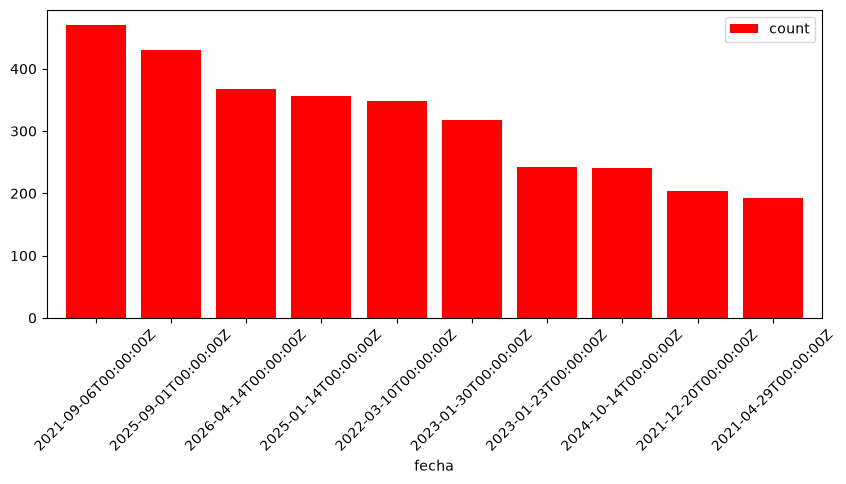

In [26]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)


In [27]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = data['nombre_articulo'].value_counts().reset_index()
Tabla_freq

,nombre_articulo,count
0,LAPTOP G,35
1,FRESA ROTO RFID 2.5 ZI DM,26
2,CERAMILL MATCH 2 CAM DONGLE,25
3,FRESA ROTO RFID 0.6 ZI DM,24
4,MEDIT INTRA ORAL SCANNER I700,23
...,...,...
3693,DISCO ZOLID BION C2 98 X 16 F,1
3694,DISCO ZOLID BION B2 98 X 16 F,1
3695,DISCO ZOLID BION A3.5 98 X 16 F,1
3696,DISCO ZOLID BION A2 98 X 25 F,1


In [28]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>18]
Filtro

,nombre_articulo,count
0,LAPTOP G,35
1,FRESA ROTO RFID 2.5 ZI DM,26
2,CERAMILL MATCH 2 CAM DONGLE,25
3,FRESA ROTO RFID 0.6 ZI DM,24
4,MEDIT INTRA ORAL SCANNER I700,23
5,FRESA ROTO RFID 1.0 ZI DM,23
6,CAMEO PRESS INGOT BOX HT A2,22
7,FRESA ROTO RFID 0.3 ZI,22
8,FRESA ROTO RFID 1.0 SC DM,21
9,FRESA DIAMOND RFID 1.8 DM,19


In [29]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('nombre_articulo')
Filtro_index

,count
nombre_articulo,
LAPTOP G,35
FRESA ROTO RFID 2.5 ZI DM,26
CERAMILL MATCH 2 CAM DONGLE,25
FRESA ROTO RFID 0.6 ZI DM,24
MEDIT INTRA ORAL SCANNER I700,23
FRESA ROTO RFID 1.0 ZI DM,23
CAMEO PRESS INGOT BOX HT A2,22
FRESA ROTO RFID 0.3 ZI,22
FRESA ROTO RFID 1.0 SC DM,21


<Axes: xlabel='nombre_articulo'>

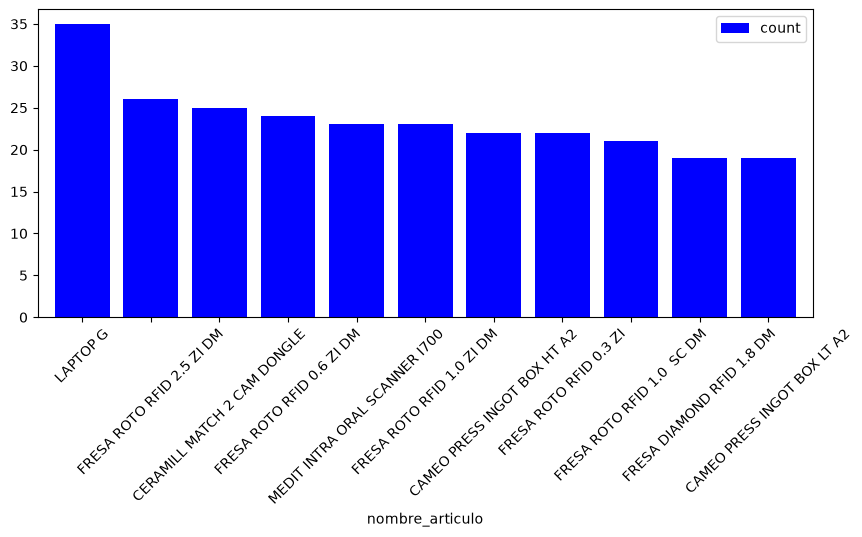

In [30]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)


In [32]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = data['unidades'].value_counts().reset_index()
Tabla_freq

,unidades,count
0,5,1113
1,10,966
2,1,775
3,2,740
4,3,550
...,...,...
256,151,1
257,295,1
258,234,1
259,281,1


In [33]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>200]
Filtro

,unidades,count
0,5,1113
1,10,966
2,1,775
3,2,740
4,3,550
5,20,483
6,15,464
7,30,403
8,50,253
9,4,229


In [35]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('unidades')
Filtro_index

,count
unidades,
5,1113
10,966
1,775
2,740
3,550
20,483
15,464
30,403
50,253


<Axes: xlabel='unidades'>

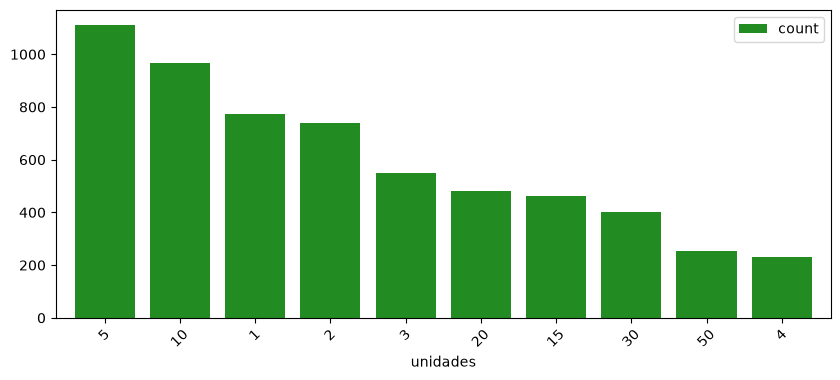

In [36]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "forestgreen", rot=45)


In [ ]:
#Procedimiento para clasificación de articulos
#nombre_articulo, categoria
data2.info()

<class 'pandas.DataFrame'>
RangeIndex: 18462 entries, 0 to 18461
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   articulo_id      18462 non-null  int64
 1   nombre_articulo  18462 non-null  str  
 2   categoria        18462 non-null  str  
dtypes: int64(1), str(2)
memory usage: 432.8 KB


In [38]:
valores_nulos=data2.isnull().sum()
print(valores_nulos)

articulo_id        0
nombre_articulo    0
categoria          0
dtype: int64


In [51]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = data2['nombre_articulo'].value_counts().reset_index()
Tabla_freq

,nombre_articulo,count
0,ZOLID GEN-X A3 98X16 F ZRO2,8
1,DISCO ZOLID BION BL1 98 X 16 F,8
2,ARTEX TYP CR,7
3,ROTO RFID 0.6 DC BLM 0.6 MM,7
4,ZOLID NATURALS VIO,7
...,...,...
5467,"ALUMINUM ALLOY RESIN TANK (9.3"" NFEP FILM)",1
5468,MAX CROWN KIT SET,1
5469,TOOL LENGTH SENSOR MOTION 2 O 3,1
5470,ARMARIO DENTAL S8 CON 8 CAJONES,1


In [55]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>5]
Filtro

,nombre_articulo,count
0,ZOLID GEN-X A3 98X16 F ZRO2,8
1,DISCO ZOLID BION BL1 98 X 16 F,8
2,ARTEX TYP CR,7
3,ROTO RFID 0.6 DC BLM 0.6 MM,7
4,ZOLID NATURALS VIO,7
5,DYNAMIC FOOT CONTROL,6
6,FLOAT SINTERIZACION DISCO 2,6
7,PHROZEN AQUA 4K RESIN GRAY 1KG,6
8,PHROZEN AQUA 8K RESIN GRAY 1KG,6
9,PILAR CRCO ANTIRROTATIVO Ø 3.5,6


In [56]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('nombre_articulo')
Filtro_index

,count
nombre_articulo,
ZOLID GEN-X A3 98X16 F ZRO2,8
DISCO ZOLID BION BL1 98 X 16 F,8
ARTEX TYP CR,7
ROTO RFID 0.6 DC BLM 0.6 MM,7
ZOLID NATURALS VIO,7
DYNAMIC FOOT CONTROL,6
FLOAT SINTERIZACION DISCO 2,6
PHROZEN AQUA 4K RESIN GRAY 1KG,6
PHROZEN AQUA 8K RESIN GRAY 1KG,6


<Axes: xlabel='nombre_articulo'>

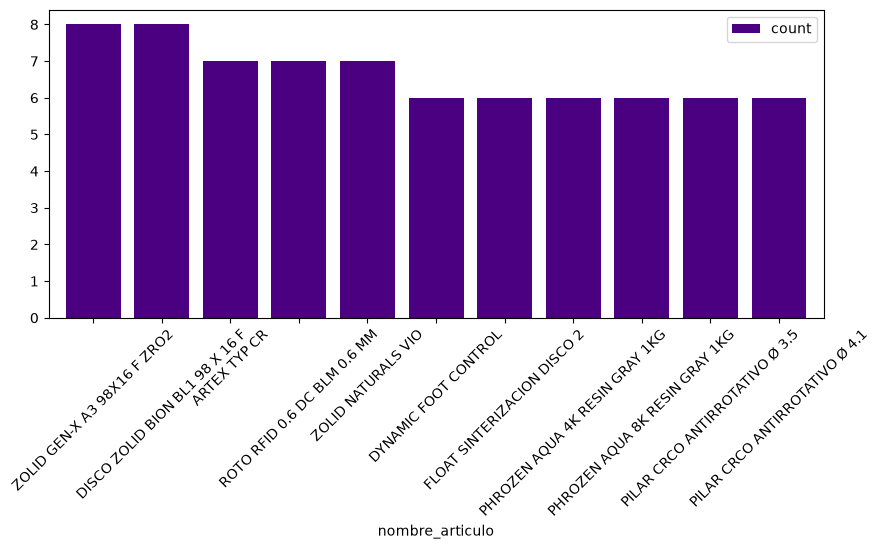

In [57]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "indigo", rot=45)

In [58]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = data2['categoria'].value_counts().reset_index()
Tabla_freq

,categoria,count
0,Consumible,4364
1,Analogo,4146
2,Dientes,1280
3,Digital,1267
4,Ceramica De Recubrimiento,1172
...,...,...
148,Fresas De Calibracion,1
149,Ceramica Para Metal,1
150,Horno De Coccion,1
151,Fresas Diamond Rfid,1


In [65]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>236]
Filtro

,categoria,count
0,Consumible,4364
1,Analogo,4146
2,Dientes,1280
3,Digital,1267
4,Ceramica De Recubrimiento,1172
5,Anterior Superior,569
6,Refaccion,342
7,Fresones,332
8,Discos,283
9,Posterior Inferior,237


In [66]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('categoria')
Filtro_index

,count
categoria,
Consumible,4364
Analogo,4146
Dientes,1280
Digital,1267
Ceramica De Recubrimiento,1172
Anterior Superior,569
Refaccion,342
Fresones,332
Discos,283


<Axes: xlabel='categoria'>

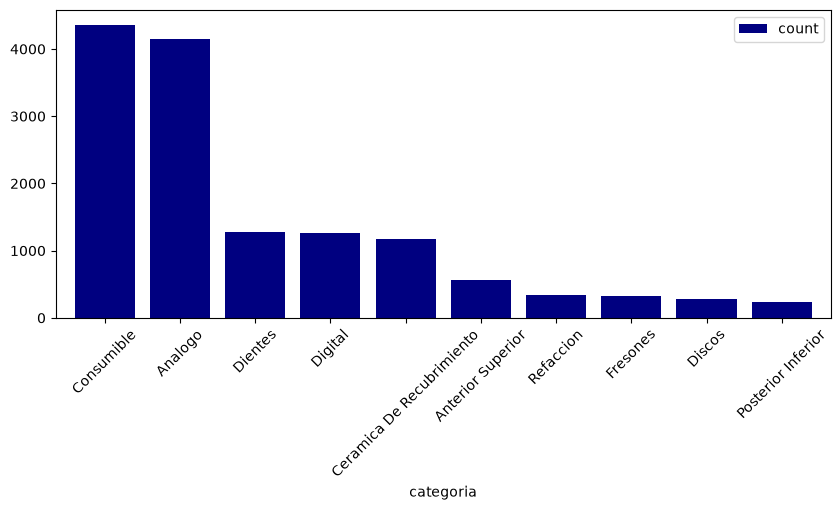

In [67]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "navy", rot=45)